In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

sns.set_style('darkgrid')

In [2]:
url = "https://raw.githubusercontent.com/Chinmaybharadwaj7/Sample-Dataset/main/netflix_titles.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [4]:
#df information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [5]:
#Finding if there are any null/missing values in Columns/features with their counts
print("Missing values before cleaning:")
df.isnull().sum()

Missing values before cleaning:


,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


In [6]:
# 1. Handle missing values in 'director' and 'cast'
# Since these are text fields and many are missing, we'll fill them with 'Unknown'.
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')

In [7]:
# 2. Handle missing 'country'
# We'll fill with the mode, which is the most common country.
mode_country = df['country'].mode()[0]
df['country'] = df['country'].fillna(mode_country)

In [8]:
# 3. Drop the few rows with missing 'date_added' and 'rating'
# Since the number is small (less than 0.2% of data), dropping them is a safe option.
df.dropna(subset=['date_added', 'rating'], inplace=True)

In [9]:
# 4. Convert 'date_added' to datetime objects
# Use format='mixed' to handle potential variations in date formats
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed', dayfirst=False)

In [10]:
# 5. Create new features for year and month added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

In [11]:
# Verify our cleaning and transformation
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData types after transformation:")
print(df.dtypes)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
month_added     0
dtype: int64

Data types after transformation:
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
year_added               int32
month_added              int32
dtype: object


### Step 4: Exploratory Data Analysis & Visualization

#### 4.1 What is the distribution of content type?

In [12]:
type_counts = df['type'].value_counts()
type_counts


,count
type,
Movie,5372
TV Show,2398


In [13]:
labels=type_counts.index
labels

Index(['Movie', 'TV Show'], dtype='object', name='type')

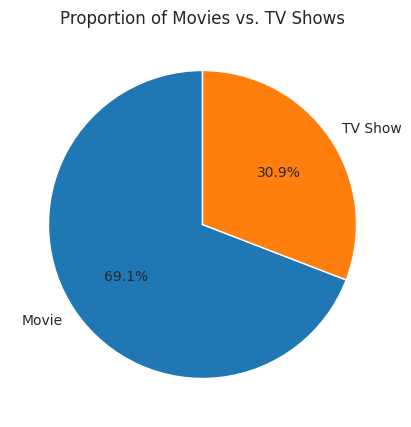

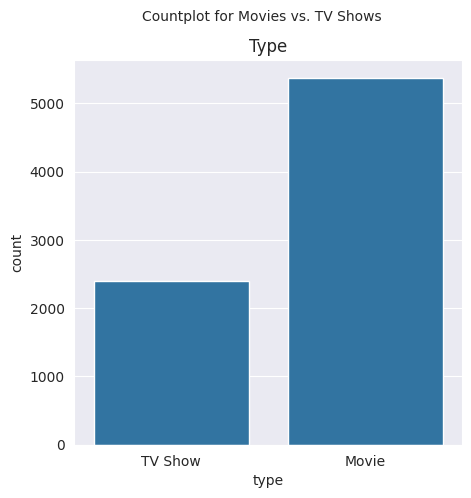

In [14]:
#Pie chart for distribution
plt.figure(figsize=(5,5))
type_counts = df['type'].value_counts()
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Proportion of Movies vs. TV Shows')
plt.ylabel('')
plt.show()

#Countplot for count
fig, axes = plt.subplots(1,1,figsize = (5,5))
fig.suptitle('Countplot for Movies vs. TV Shows',fontsize = 10)
sns.countplot(ax=axes,x = 'type', data = df).set_title('Type')
plt.show()

**Insight:** The Netflix library is dominated by Movies, which make up roughly 70% of the content in this dataset.

#### 4.2 How has content been added over time?

In [15]:
content_over_time = df.groupby(['year_added', 'type'])
content_over_time

In [16]:
content_over_time.size()

year_added  type   
2008        Movie         1
            TV Show       1
2009        Movie         2
2010        Movie         1
2011        Movie        13
2012        Movie         3
2013        Movie         6
            TV Show       5
2014        Movie        19
            TV Show       6
2015        Movie        58
            TV Show      30
2016        Movie       256
            TV Show     184
2017        Movie       861
            TV Show     361
2018        Movie      1255
            TV Show     429
2019        Movie      1497
            TV Show     656
2020        Movie      1312
            TV Show     697
2021        Movie        88
            TV Show      29
dtype: int64

In [17]:
#unstack() pivots one level of the row index into columns.
content_over_time.size().unstack()

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,NaN
2010,1.0,NaN
2011,13.0,NaN
2012,3.0,NaN
2013,6.0,5.0
2014,19.0,6.0
2015,58.0,30.0
2016,256.0,184.0


In [18]:
#Find the Null values
content_over_time.size().unstack().isnull().sum()

,0
type,
Movie,0
TV Show,4


In [19]:
#Fill empty cells (NaN) with 0 for both type
content_over_time.size().unstack().fillna(0)

type,Movie,TV Show
year_added,,
2008,1.0,1.0
2009,2.0,0.0
2010,1.0,0.0
2011,13.0,0.0
2012,3.0,0.0
2013,6.0,5.0
2014,19.0,6.0
2015,58.0,30.0
2016,256.0,184.0


<Figure size 1400x800 with 0 Axes>

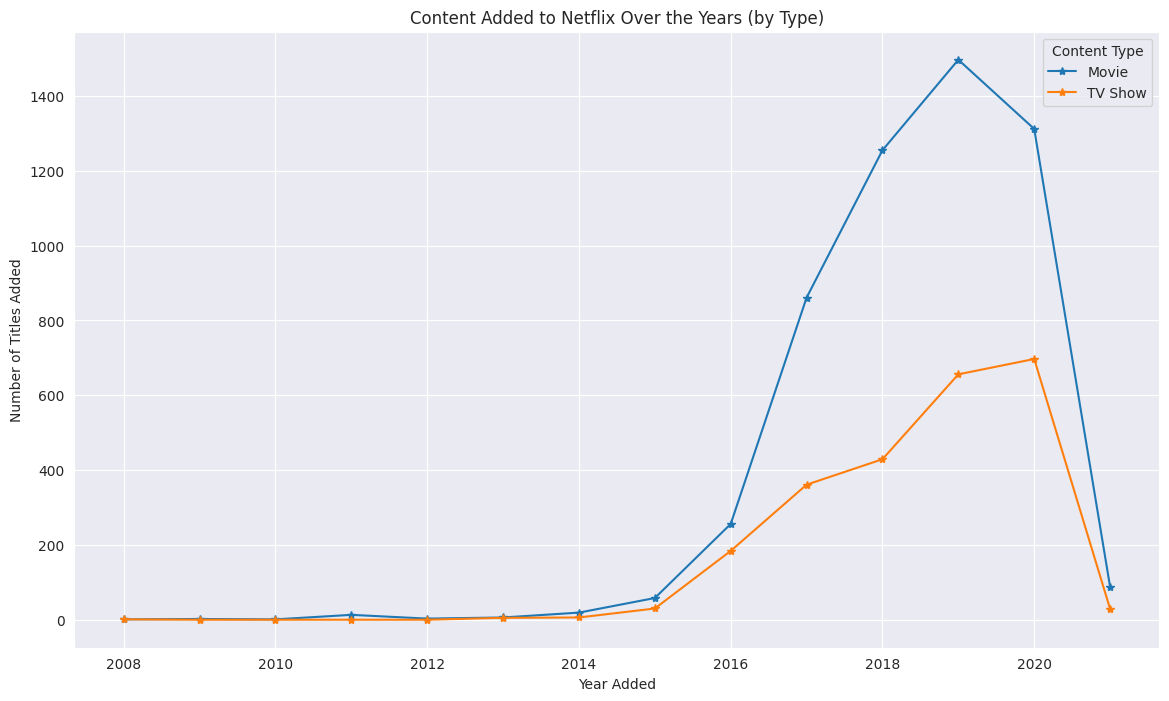

In [20]:
# Group data by year and content type
content_over_time = df.groupby(['year_added', 'type']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='*', figsize=(14, 8))
plt.title('Content Added to Netflix Over the Years (by Type)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.legend(title='Content Type')
plt.grid(True)
plt.show()

**Insight:** By separating movies and TV shows, we can see that while both grew significantly, the addition of movies accelerated much more dramatically, peaking in 2019. The growth in TV shows has been more steady. There appears to be a slight slowdown in content additions in 2020 and 2021, which could be due to the COVID-19 pandemic affecting productions or the dataset being incomplete for the latest year.

#### 4.3 What are the most popular genres?

In [21]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


In [22]:
#Extract genres and separate them from 'Listed_in'
genre=df['listed_in'].str.split(', ')
genre

,listed_in
0,"[International TV Shows, TV Dramas, TV Sci-Fi ..."
1,"[Dramas, International Movies]"
2,"[Horror Movies, International Movies]"
3,"[Action & Adventure, Independent Movies, Sci-F..."
4,[Dramas]
...,...
7782,"[Dramas, International Movies]"
7783,"[Dramas, International Movies, Music & Musicals]"
7784,"[Documentaries, International Movies, Music & ..."
7785,"[International TV Shows, Reality TV]"


In [23]:
#Include that in df
df.assign(genre=df['listed_in'].str.split(', '))

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,"[International TV Shows, TV Dramas, TV Sci-Fi ..."
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,"[Dramas, International Movies]"
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,"[Horror Movies, International Movies]"
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,"[Action & Adventure, Independent Movies, Sci-F..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,[Dramas]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10,"[Dramas, International Movies]"
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,"[Dramas, International Movies, Music & Musicals]"
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,"[Documentaries, International Movies, Music & ..."
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,"[International TV Shows, Reality TV]"


In [24]:
# explode it
#explode() is used to transform a list-like column (a column that contains lists, tuples, or arrays) into multiple rows — one item per row.
genres = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
genres

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Dramas
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,TV Sci-Fi & Fantasy
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,Dramas
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,Music & Musicals
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,International TV Shows
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,Reality TV
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,Unknown,"United Kingdom, Canada, United States",2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3,Documentaries


In [25]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts()
top_genres_counts

,count
genre,
International Movies,2437
Dramas,2105
Comedies,1471
International TV Shows,1197
Documentaries,786
Action & Adventure,721
TV Dramas,703
Independent Movies,673
Children & Family Movies,532


In [26]:
#show index
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts

,genre,count
0,International Movies,2437
1,Dramas,2105
2,Comedies,1471
3,International TV Shows,1197
4,Documentaries,786
5,Action & Adventure,721
6,TV Dramas,703
7,Independent Movies,673
8,Children & Family Movies,532
9,Romantic Movies,531


In [27]:
# Rename columns for clarity
top_genres_counts.columns = ['genre', 'count']

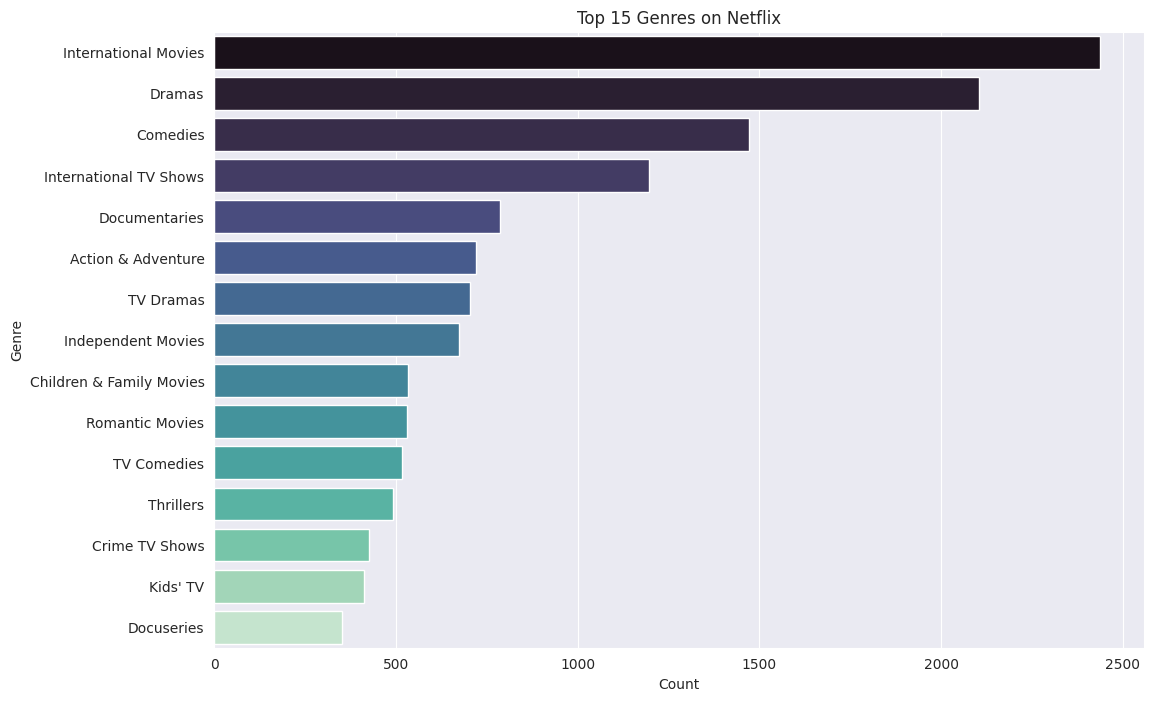

In [28]:
# Get the top 15 genres and their counts
top_genres_counts = genres['genre'].value_counts().reset_index()
top_genres_counts.columns = ['genre', 'count'] # Rename columns for clarity

# Select only the top 15 for plotting
top_genres_counts_plot = top_genres_counts.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(y='genre', x='count', data=top_genres_counts_plot, palette='mako', hue='genre', legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()

**Insight:** "International Movies" is the most common genre tag, highlighting Netflix's global content strategy. This is followed by Dramas, Comedies, and Action & Adventure.

#### 4.4 What is the distribution of content duration?

In [29]:
# Separate movies and TV shows
movies_df = df[df['type'] == 'Movie'].copy()
tv_shows_df = df[df['type'] == 'TV Show'].copy()

In [30]:
# Clean and convert duration for movies
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(int)

# Clean and convert duration for TV shows
tv_shows_df['seasons'] = tv_shows_df['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

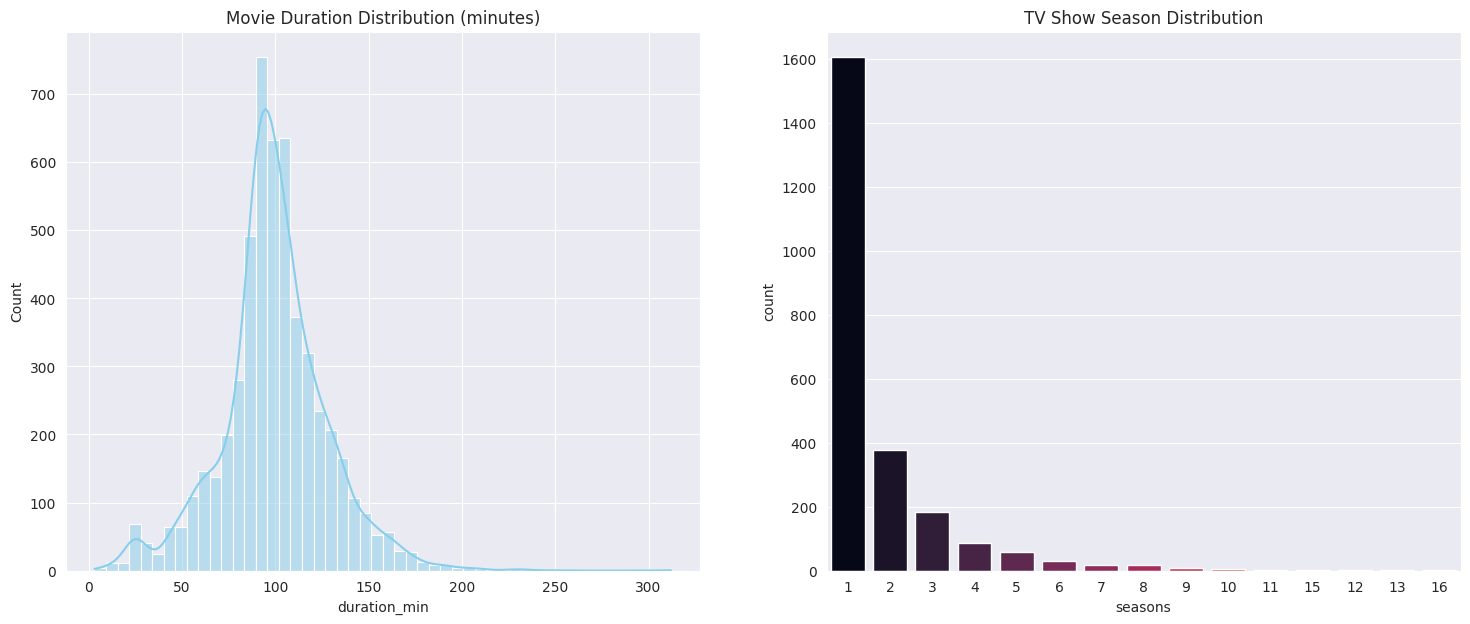

In [31]:
# Plot the distributions
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Movie Duration Distribution
sns.histplot(ax=axes[0], data=movies_df, x='duration_min', bins=50, kde=True, color='skyblue').set_title('Movie Duration Distribution (minutes)')

# TV Show Season Distribution
sns.countplot(ax=axes[1], x='seasons', data=tv_shows_df, palette='rocket', order=tv_shows_df['seasons'].value_counts().index, hue='seasons', legend=False).set_title('TV Show Season Distribution')

plt.show()

**Insight:**
- The majority of movies on Netflix are between 80 and 120 minutes long, which is standard for feature films.
- The vast majority of TV shows on Netflix are short-lived, with most having only 1 season. This could reflect a strategy of producing many pilots and only renewing the most successful ones, or a focus on limited series.

#### 4.5 Where does the content come from? (Geographical Analysis)

In [32]:
df['country']

,country
0,Brazil
1,Mexico
2,Singapore
3,United States
4,United States
...,...
7782,"Sweden, Czech Republic, United Kingdom, Denmar..."
7783,India
7784,United States
7785,Australia


In [33]:
# Handle the multi-country listings similar to genres
countries = df.assign(country=df['country'].str.split(', ')).explode('country')

In [34]:
# Get the top 15 countries and their counts
top_countries_counts = countries['country'].value_counts().reset_index()
top_countries_counts.columns = ['country', 'count'] # Rename columns for clarity

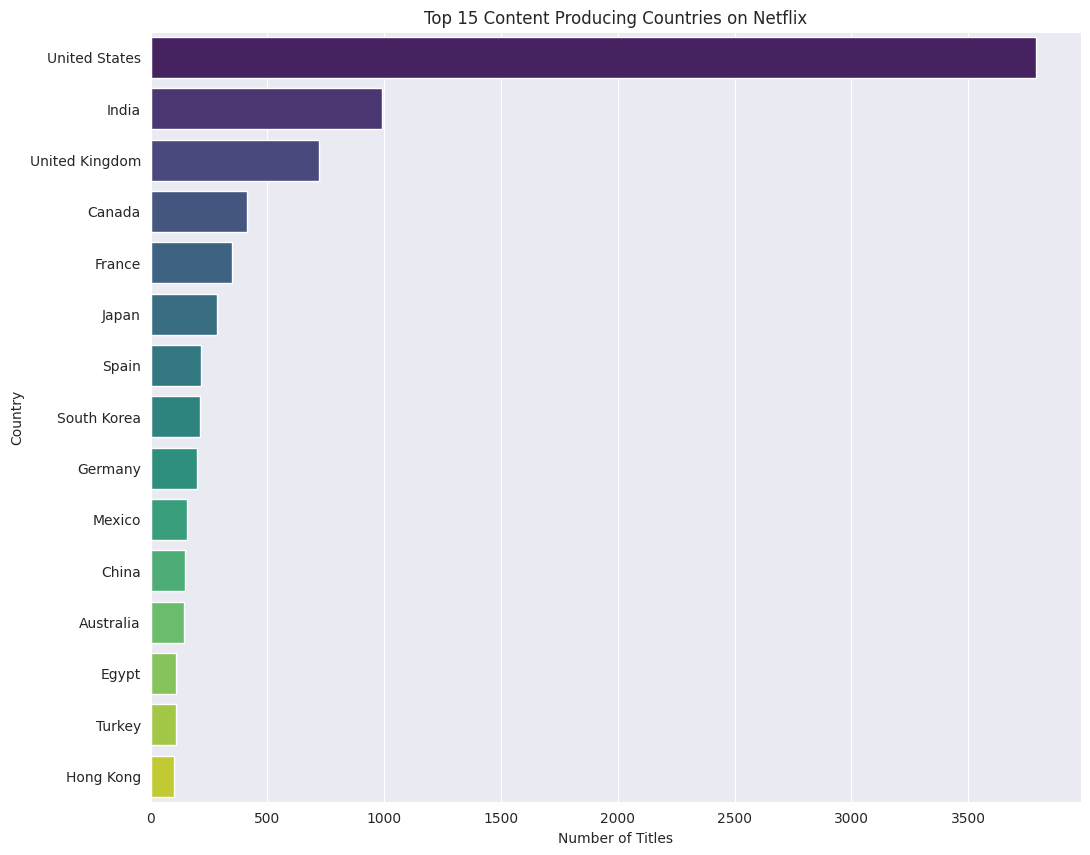

In [35]:
# Select only the top 15 for plotting
top_countries_counts_plot = top_countries_counts.head(15)

plt.figure(figsize=(12, 10))
sns.barplot(y='country', x='count', data=top_countries_counts_plot, palette='viridis', hue='country', legend=False)
plt.title('Top 15 Content Producing Countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

**Insight:** The United States is by far the largest producer of content available on Netflix. However, India is a very strong second, which explains why so many of the top actors were from India. The UK, Japan, and South Korea also represent major content markets for the platform, emphasizing its global nature.

#### 4.6 What are the maturity ratings of the content?

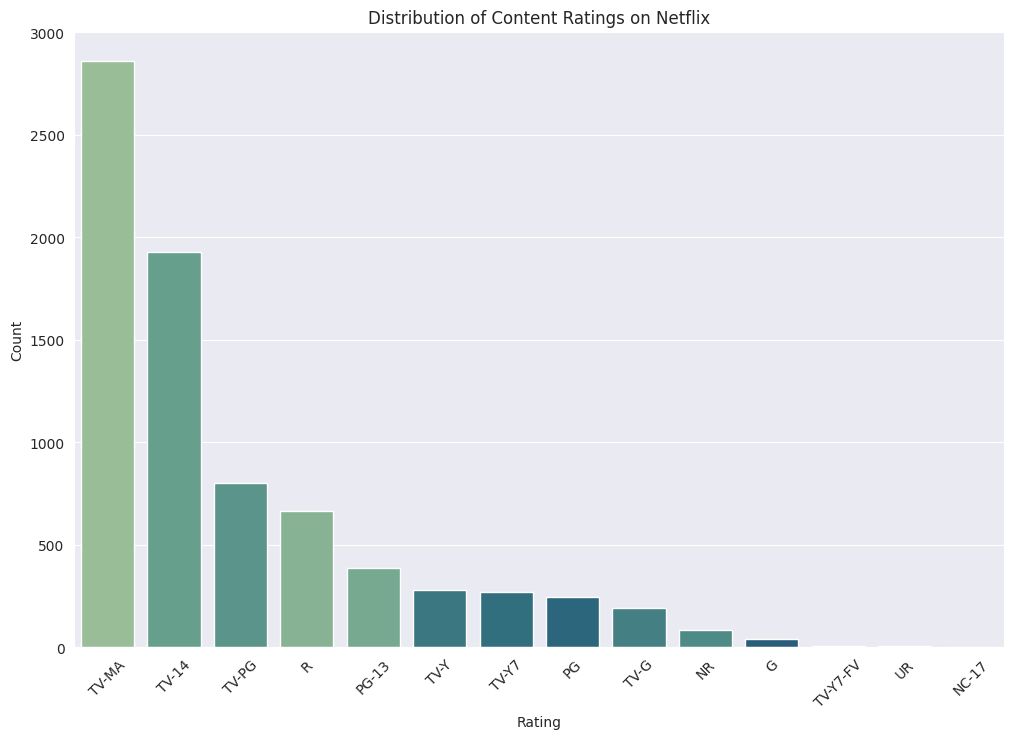

In [36]:
plt.figure(figsize=(12, 8))
sns.countplot(x='rating', data=df, order=df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.title('Distribution of Content Ratings on Netflix')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

**Insight:** A large portion of Netflix's content is aimed at mature audiences, with `TV-MA` (Mature Audience) and `TV-14` (Parents Strongly Cautioned) being the two most common ratings. This suggests a focus on adult viewers over content for children (`TV-G`, `TV-Y`).

**Insight:** By the result we can see that TV-MA has grown more significally

### Step 5: Feature Engineering - Content Freshness
Let's create a new feature to analyze how old content is when it gets added to Netflix. This can tell us about their acquisition strategy (buying old classics vs. releasing new originals).

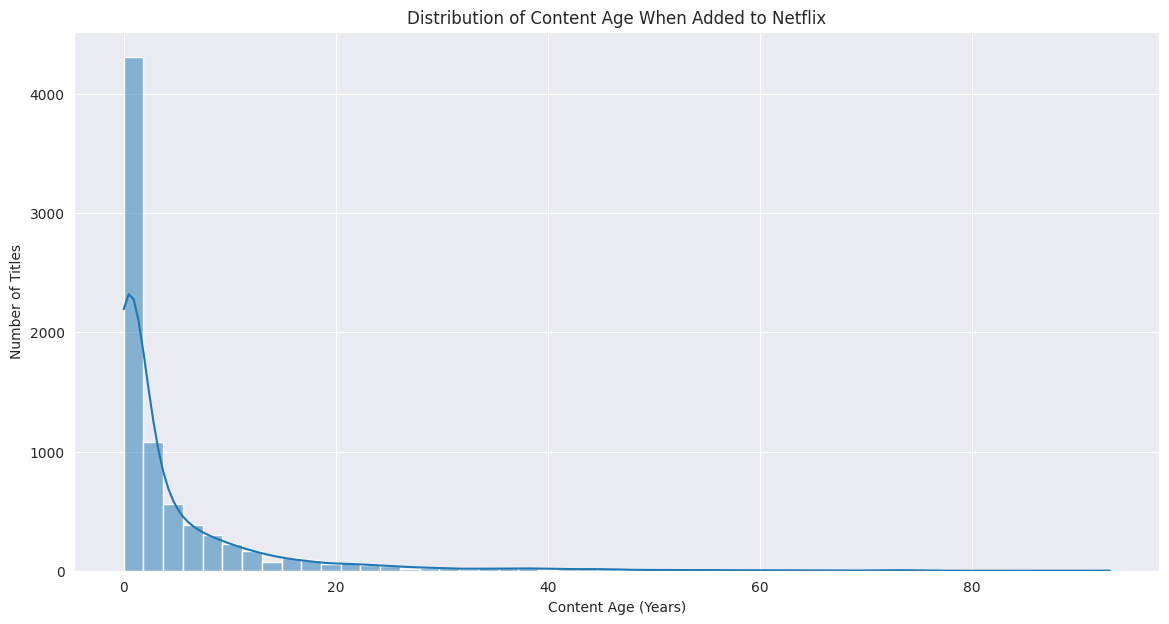

In [37]:
# Create the 'age_on_netflix' feature
df['age_on_netflix'] = df['year_added'] - df['release_year']

# Filter out any potential errors where added_year is before release_year
content_age = df[df['age_on_netflix'] >= 0]

plt.figure(figsize=(14, 7))
sns.histplot(data=content_age, x='age_on_netflix', bins=50, kde=True)
plt.title('Distribution of Content Age When Added to Netflix')
plt.xlabel('Content Age (Years)')
plt.ylabel('Number of Titles')
plt.show()

**Insight:** The large spike at `0` indicates that a significant amount of content is added in the same year it's released, which is characteristic of "Netflix Originals." However, there is a very long tail, showing that Netflix also heavily invests in acquiring licensed content that can be decades old, building a deep library of classic films and shows.

### Step 6: Deeper Multivariate Analysis

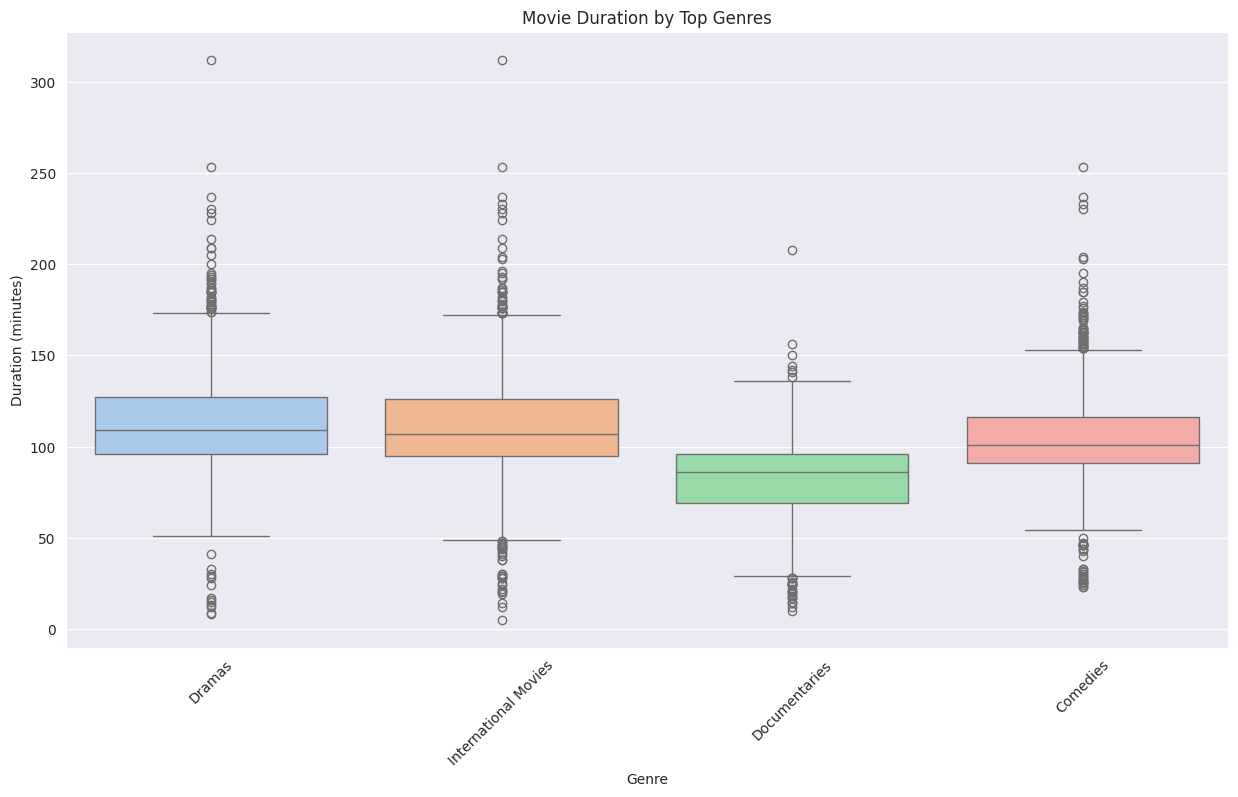

In [38]:
# Analyze movie duration across different top genres
top_genres = genres['genre'].value_counts().index[:5]
genres_movies = genres[(genres['type'] == 'Movie') & (genres['genre'].isin(top_genres))].copy()
genres_movies['duration_min'] = genres_movies['duration'].str.replace(' min', '').astype(int)

plt.figure(figsize=(15, 8))
sns.boxplot(data=genres_movies, x='genre', y='duration_min', palette='pastel', hue='genre', legend=False)
plt.title('Movie Duration by Top Genres')
plt.xlabel('Genre')
plt.ylabel('Duration (minutes)')
plt.xticks(rotation=45)
plt.show()

**Insight:** While the median duration for most top genres is similar (around 90-100 minutes), we can see some interesting variations. For example, Dramas tend to have a wider range of durations, with many longer films. International Movies also show a broad distribution, reflecting diverse filmmaking styles from around the world.

### Step 7: Word Cloud from Content Descriptions
As a final visual analysis, let's generate a word cloud from the `description` column to see what themes and words are most common in Netflix content.

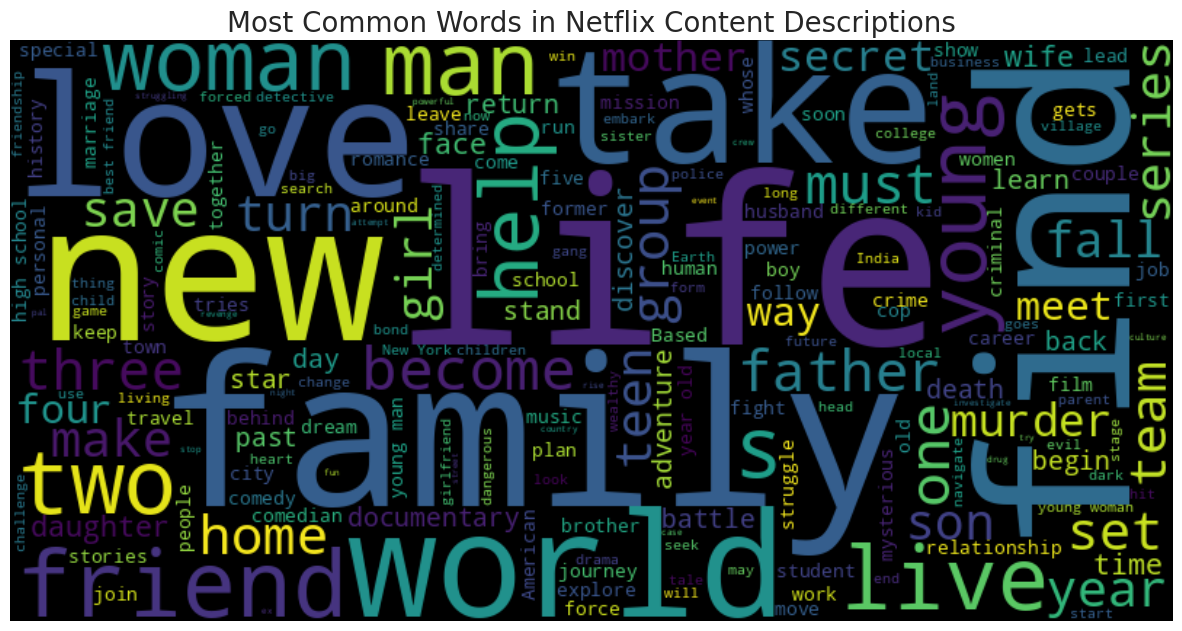

In [39]:
# Combine all descriptions into a single string
text = ' '.join(df['description'])

# Create and generate a word cloud image
wordcloud = WordCloud(width=800, height=400, background_color='black').generate(text)

# Display the generated image
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Content Descriptions', fontsize=20)
plt.show()

**Insight:** The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys. Action-oriented words like "find," "secret," and "new" also appear frequently.

# Submission Q's

###1. How has the distribution of content ratings changed over time?

<Figure size 1400x800 with 0 Axes>

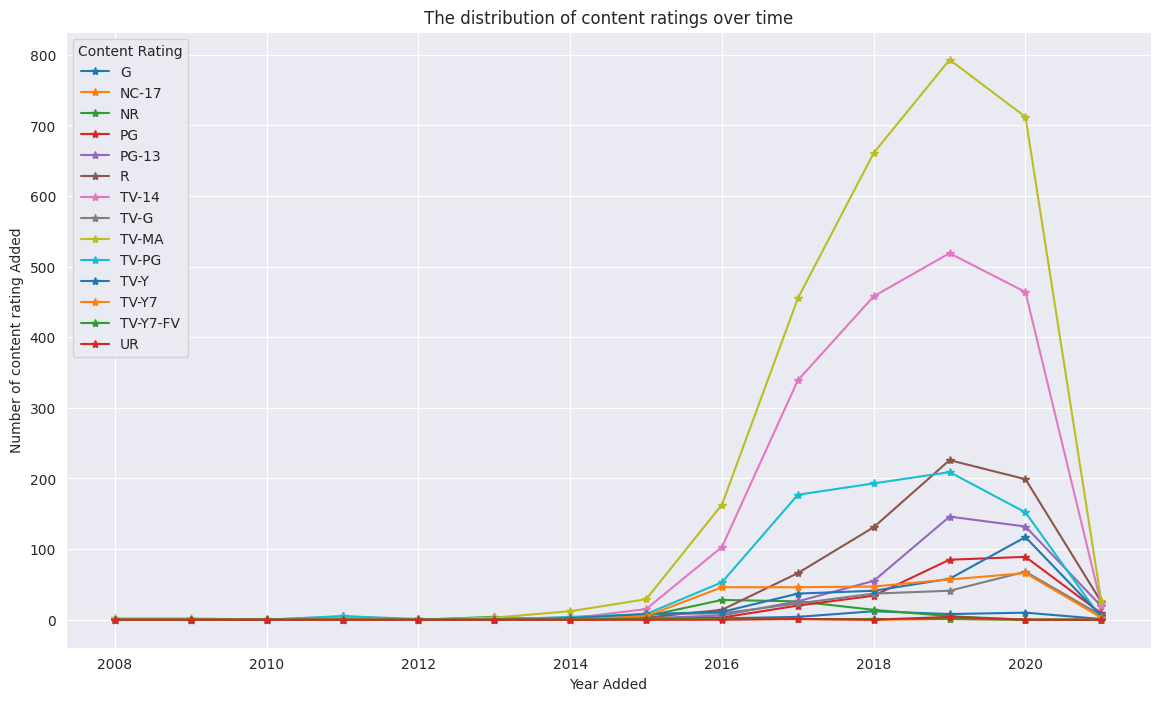

In [40]:
# Group data by year and content type
content_over_time = df.groupby(['year_added', 'rating']).size().unstack().fillna(0)

plt.figure(figsize=(14, 8))
content_over_time.plot(kind='line', marker='*', figsize=(14, 8))
plt.title('The distribution of content ratings over time')
plt.xlabel('Year Added')
plt.ylabel('Number of content rating Added')
plt.legend(title='Content Rating')
plt.grid(True)
plt.show()

**Insight:** Netflix has progressively shifted from a balanced, family-inclusive catalog to one dominated by mature content (TV-MA and TV-14), especially after 2015.

###2. Is there a relationship between content age and its type (Movie vs. TV Show)?

In [41]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,age_on_netflix
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,7
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,8
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,12


In [42]:
df['age_on_netflix'].unique()

array([ 0,  7,  8, 12,  1, 22,  9,  5,  2,  3, 13,  4, 11,  6, 20, 16, 10,
       30, 43, 49, 25, 14, 21, 23, 24, 18, 29, 17, 41, 31, 38, 45, 42, 19,
       51, 32, 27, 26, -1, 39, 28, 47, 37, 15, 40, 46, 54, 59, 62, 61, 52,
       44, 64, 33, 36, 35, 34, 48, 63, -3, 72, 71, 57, 93, 75, 55, 65, -2,
       50, 66, 73, 70, 58, 74])

In [43]:
#we can see neagtive values in age_on_netflix which mean content is added on netflix before releasing.
#we are taking new dataframe with age_on_netflix more than zero.
content_age_df = df[df['age_on_netflix'] >= 0]
content_age_df['age_on_netflix'].unique()

array([ 0,  7,  8, 12,  1, 22,  9,  5,  2,  3, 13,  4, 11,  6, 20, 16, 10,
       30, 43, 49, 25, 14, 21, 23, 24, 18, 29, 17, 41, 31, 38, 45, 42, 19,
       51, 32, 27, 26, 39, 28, 47, 37, 15, 40, 46, 54, 59, 62, 61, 52, 44,
       64, 33, 36, 35, 34, 48, 63, 72, 71, 57, 93, 75, 55, 65, 50, 66, 73,
       70, 58, 74])

In [44]:
contentage_over_type = content_age_df.groupby(['age_on_netflix', 'type']).size().unstack()
contentage_over_type

type,Movie,TV Show
age_on_netflix,,
0,1612.0,1211.0
1,1086.0,398.0
2,445.0,198.0
3,314.0,123.0
4,242.0,94.0
...,...,...
72,3.0,NaN
73,3.0,NaN
74,3.0,NaN


In [45]:
contentage_over_type = content_age_df.groupby(['age_on_netflix', 'type']).size().unstack().fillna(0)
contentage_over_type

type,Movie,TV Show
age_on_netflix,,
0,1612.0,1211.0
1,1086.0,398.0
2,445.0,198.0
3,314.0,123.0
4,242.0,94.0
...,...,...
72,3.0,0.0
73,3.0,0.0
74,3.0,0.0


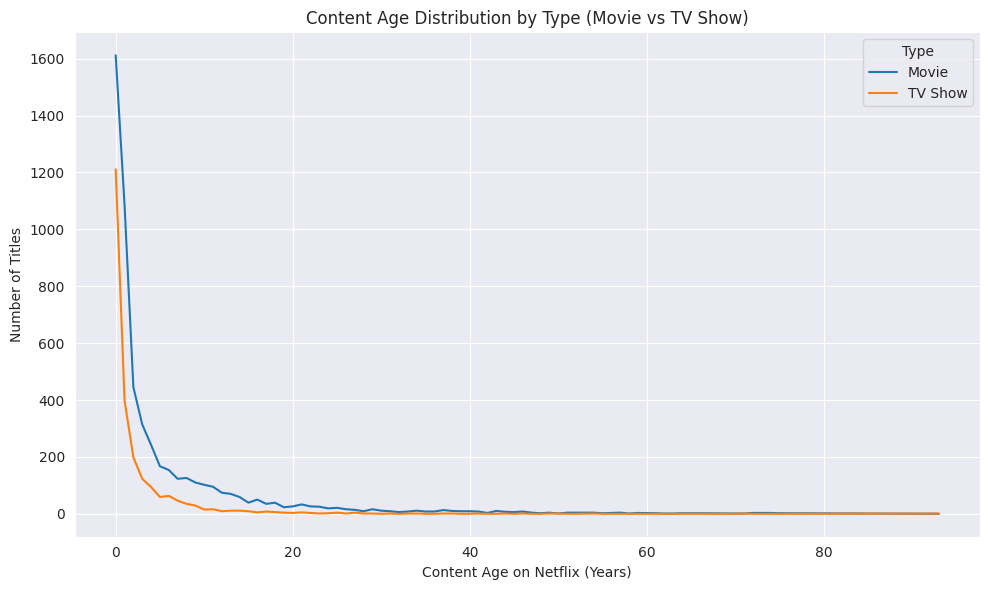

In [46]:
contentage_over_type.plot(figsize=(10, 6))

plt.xlabel("Content Age on Netflix (Years)")
plt.ylabel("Number of Titles")
plt.title("Content Age Distribution by Type (Movie vs TV Show)")
plt.legend(title="Type")
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** The diagram shows that TV Shows are mostly added to Netflix shortly after release and decline rapidly with age, while Movies persist across a much wider age range. This indicates a strong relationship between content age and type, driven by different acquisition and retention strategies.

### 3. Can we identify any trends in content production based on the release year vs. the year added to Netflix?

In [47]:
#we need to find the average year gap from release_date to year_added. And then we need plot the diagram.
gap_trend = content_age_df.groupby('release_year')['age_on_netflix'].mean()
gap_trend

,age_on_netflix
release_year,
1925,93.000000
1942,75.000000
1943,74.000000
1944,73.000000
1945,72.000000
...,...
2017,0.991080
2018,0.621646
2019,0.291037


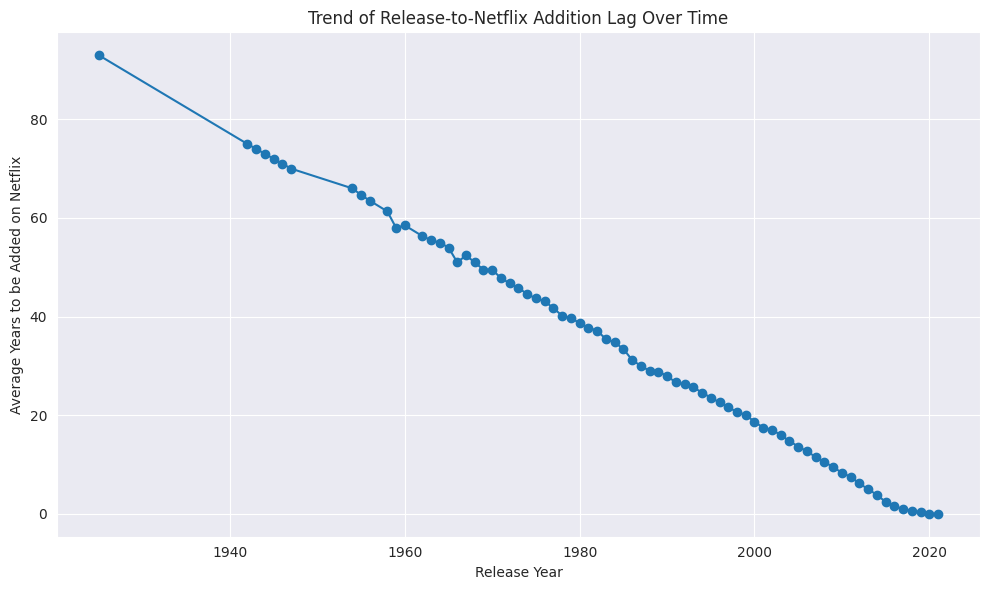

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(gap_trend.index, gap_trend.values, marker='o')
plt.xlabel("Release Year")
plt.ylabel("Average Years to be Added on Netflix")
plt.title("Trend of Release-to-Netflix Addition Lag Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** Netflix has progressively shortened the time between content release and platform availability, reaching near-instant addition for modern titles.

###4. What are the most common word pairs or phrases in content descriptions?

In [49]:
df['description'].head(10)


,description
0,In a future where the elite inhabit an island ...
1,After a devastating earthquake hits Mexico Cit...
2,"When an army recruit is found dead, his fellow..."
3,"In a postapocalyptic world, rag-doll robots hi..."
4,A brilliant group of students become card-coun...
5,A genetics professor experiments with a treatm...
6,"After an awful accident, a couple admitted to ..."
7,After one of his high school students attacks ...
8,"When a doctor goes missing, his psychiatrist w..."
9,An architect and his wife move into a castle t...


In [50]:
from sklearn.feature_extraction.text import CountVectorizer
# Initialize CountVectorizer for bigrams
vectorizer = CountVectorizer(stop_words='english',
    ngram_range=(2, 2),   # bigrams
    min_df=20             # appears in at least 20 descriptions
)

# Fit and transform
X = vectorizer.fit_transform(df['description'].dropna())

# Get bigram frequencies
bigram_counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

# Create DataFrame
top_bigrams = pd.DataFrame({'Phrase': bigrams,'Count': bigram_counts}).sort_values(by='Count', ascending=False).head(15)

top_bigrams


,Phrase,Count
10,high school,133
34,year old,130
39,young man,103
40,young woman,98
18,new york,86
25,small town,59
1,best friend,51
31,true story,48
27,stand special,47
33,world war,46


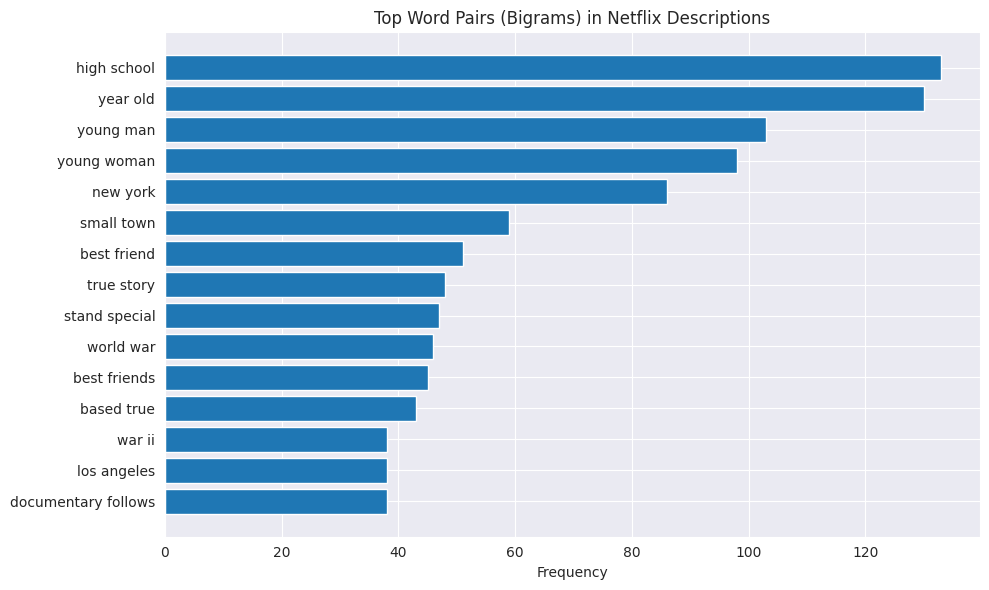

In [51]:
plt.figure(figsize=(10, 6))
plt.barh(top_bigrams['Phrase'], top_bigrams['Count'])
plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Top Word Pairs (Bigrams) in Netflix Descriptions')
plt.tight_layout()
plt.show()

**Insight:** Bigram analysis of Netflix content descriptions shows a strong emphasis on youth-centric narratives, relationship-driven storytelling, familiar settings, and real-world inspired content, with stand-up comedy emerging as a distinct and recurring category.

###5. Who are the top directors on Netflix?

In [52]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,age_on_netflix
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,7
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,8
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,12


In [53]:
df['director'].value_counts()

,count
director,
Unknown,2376
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
...,...
John Trengove,1
Jonathan Helpert,1
Jacob Schwab,1


In [54]:
# Handle the multi-director listings similar to genres
directors_df = df.assign(directors=df['director'].str.split(', ')).explode('directors')
directors_df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,age_on_netflix,directors
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,0,Unknown
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,0,Jorge Michel Grau
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,7,Gilbert Chan
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,8,Shane Acker
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,12,Robert Luketic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10,15,Josef Fares
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,4,Mozez Singh
7784,s7785,Movie,Zulu Man in Japan,Unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,1,Unknown
7785,s7786,TV Show,Zumbo's Just Desserts,Unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,1,Unknown


In [55]:
directors_df['directors'].unique()


array(['Unknown', 'Jorge Michel Grau', 'Gilbert Chan', ...,
       'Peter Hewitt', 'Josef Fares', 'Mozez Singh'], dtype=object)

In [56]:
directors_df['directors'].value_counts()

,count
directors,
Unknown,2376
Jan Suter,21
Raúl Campos,19
Marcus Raboy,16
Jay Karas,15
...,...
Shravan Kumar,1
Shane Acker,1
Gilbert Chan,1


In [57]:
top_movie_directors = directors_df[directors_df['type']== 'Movie']['directors'].value_counts().head(10)
top_tvshow_directors = directors_df[directors_df['type']== 'TV Show']['directors'].value_counts().head(10)

In [58]:
top_movie_directors

,count
directors,
Unknown,162
Jan Suter,21
Raúl Campos,19
Jay Karas,15
Marcus Raboy,15
Cathy Garcia-Molina,13
Youssef Chahine,12
Martin Scorsese,12
Jay Chapman,12


In [59]:
top_tvshow_directors

,count
directors,
Unknown,2214
Ken Burns,3
Alastair Fothergill,3
Jung-ah Im,2
Rob Seidenglanz,2
Stan Lathan,2
Lynn Novick,2
Shin Won-ho,2
Iginio Straffi,2


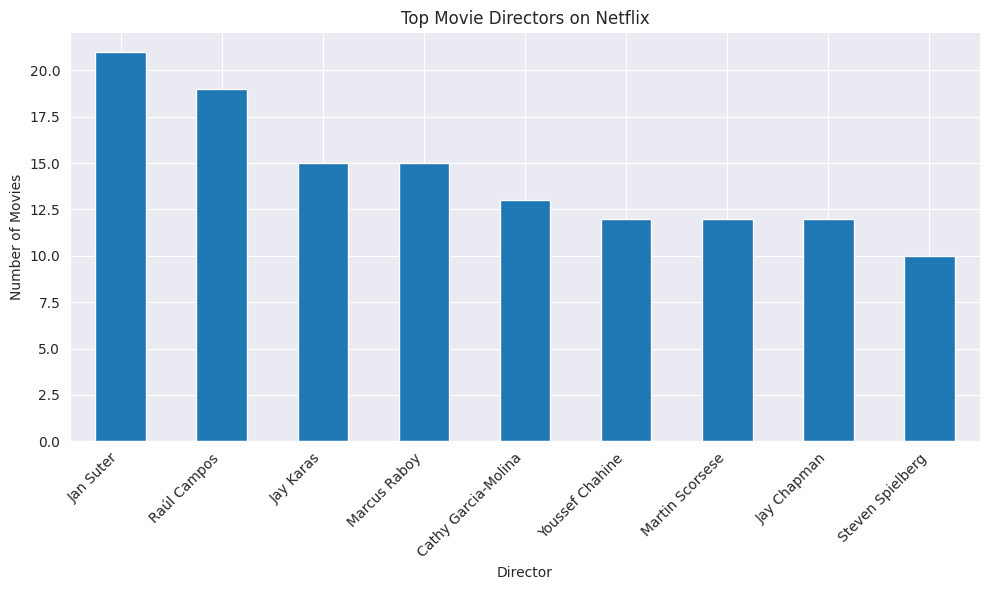

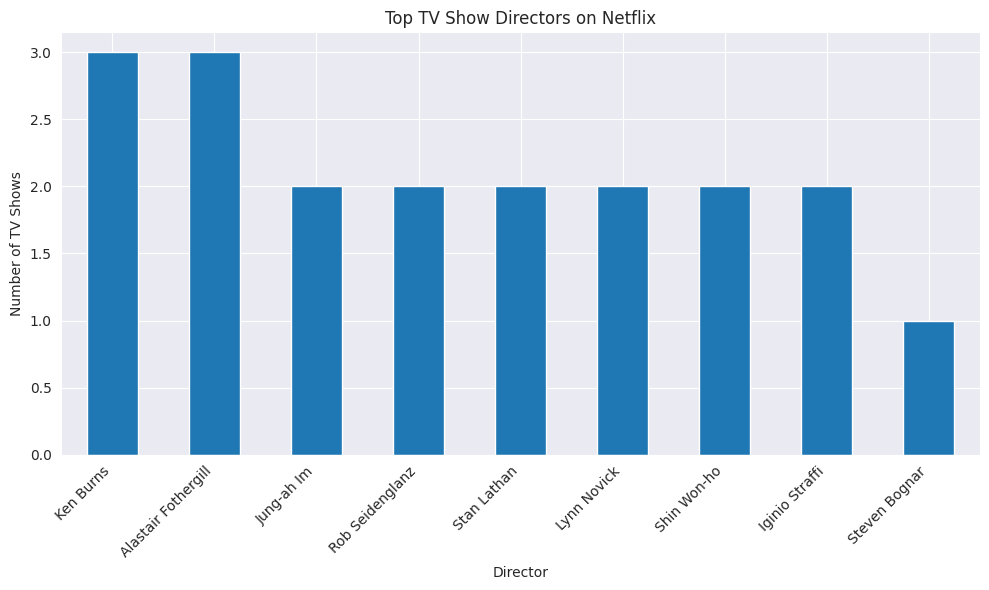

In [60]:
movie_directors_clean = top_movie_directors.drop('Unknown', errors='ignore')

plt.figure(figsize=(10, 6))
movie_directors_clean.plot(kind='bar')
plt.title("Top Movie Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


tv_directors_clean = top_tvshow_directors.drop('Unknown', errors='ignore')

plt.figure(figsize=(10, 6))
tv_directors_clean.plot(kind='bar')
plt.title("Top TV Show Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:** Based on the number of the movie/shows directed Jan Suter and Raúl Campos are the top directors for Movies and Ken Burns and
Alastair Fothergill for TV Shows. Netflix’s movie catalog exhibits repeat collaborations with a small group of high-output directors, particularly in stand-up and special-format content, while director attribution for TV shows is sparse and fragmented, limiting meaningful analysis.